In [51]:
import numpy as np
import pandas as pd
import neurokit2 as nk
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from sklearn.decomposition import PCA
import pywt

### Actividad 1

* Generar 2 señales EKG de duración 20 s
* Gráfica de forma independiente estas señales

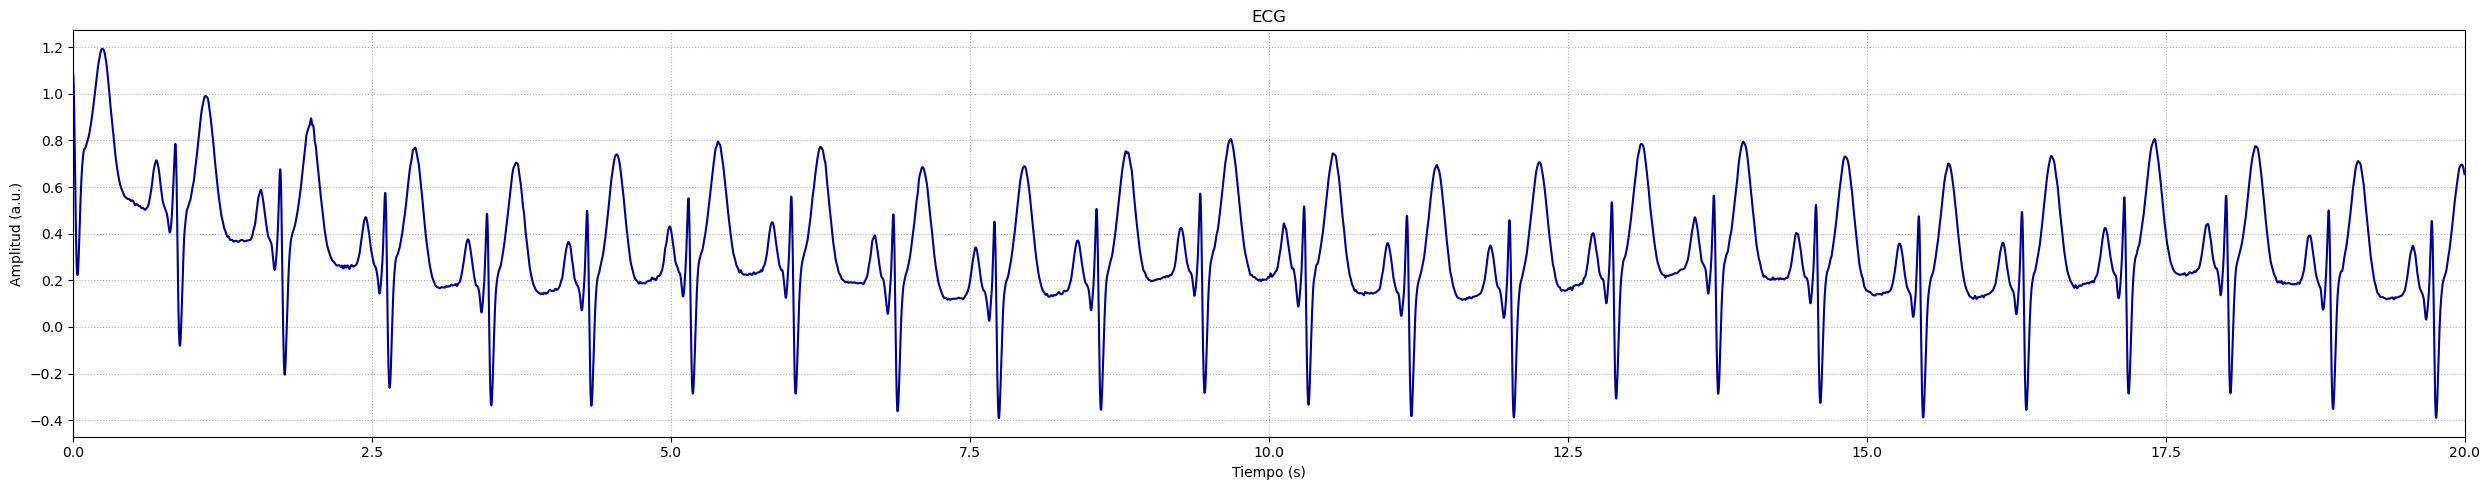

In [9]:
ti = np.array((-70, -15, 0, 15, 100))      # t, the starting position along the circle of each interval in radius
ai = np.array((1.2, -5, 30, -7.5, 0.75))   # a, the amplitude of each spike
bi = np.array((0.25, 0.1, 0.1, 0.1, 0.4))  # b, the width of each spike

ti = np.random.normal(ti, np.ones(5) * 3)
ai = np.random.normal(ai, np.abs(ai / 5))
bi = np.random.normal(bi, np.abs(bi / 5))

ecg12 = nk.ecg_simulate(duration=20, method="ecgsyn", ti=ti, ai=ai, bi=bi)
fs = 1000; t = np.linspace(0, len(ecg12) / fs, len(ecg12) );

plt.figure(figsize=(25, 5));
plt.plot(t, ecg12, color="darkblue");
plt.title("ECG");plt.xlabel("Tiempo (s)");plt.ylabel("Amplitud (a.u.)");plt.xlim(0, t[-1]);
plt.tight_layout();plt.grid(ls=":");
plt.show()

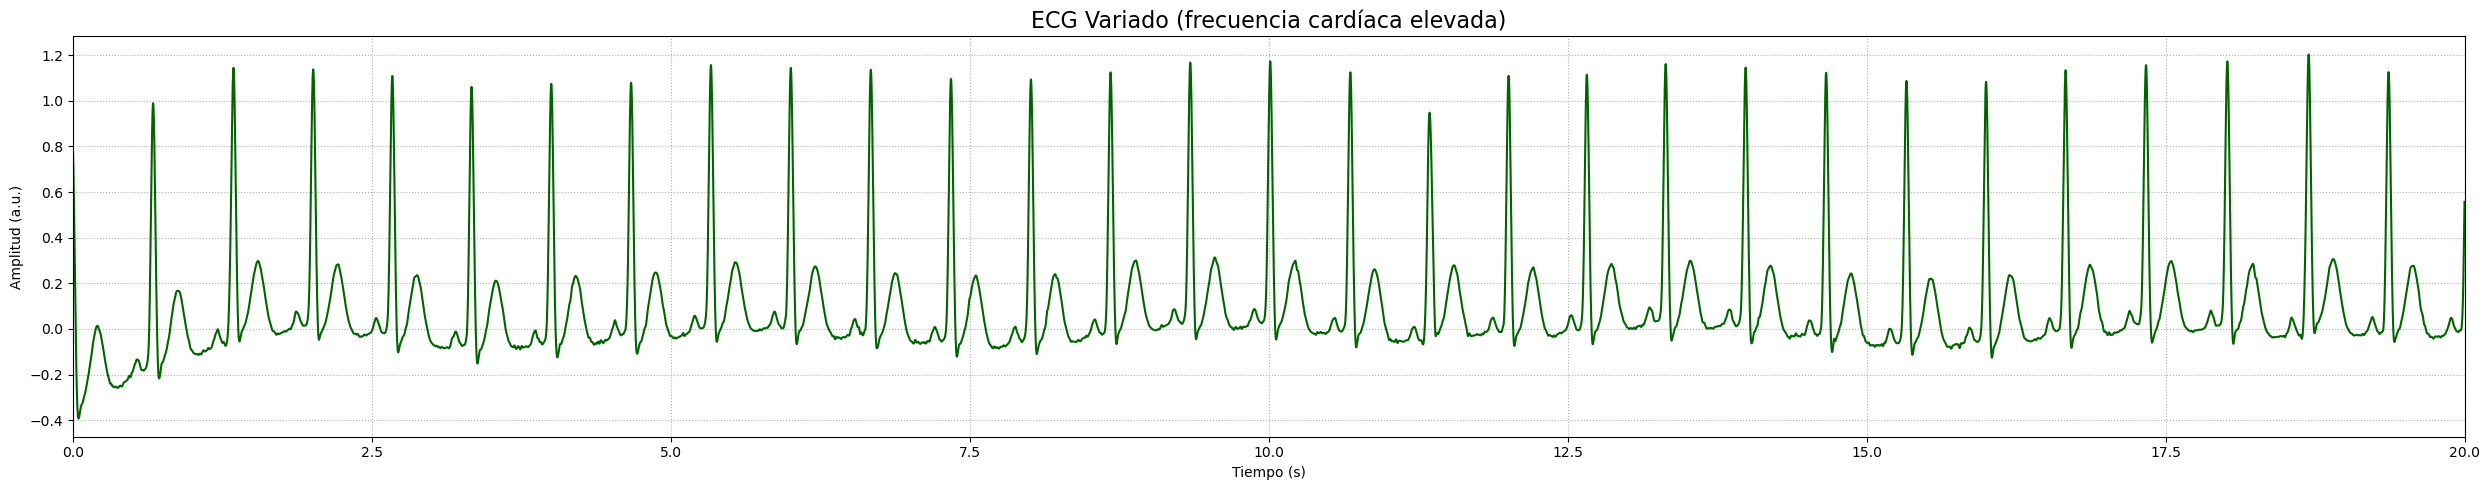

In [59]:
ai = np.array((1.0, -4.5, 25, -6.0, 0.6))  
bi = np.array((0.22, 0.08, 0.12, 0.09, 0.35)) 
ti = np.array([-70, -15, 0, 15, 100])

ti = np.random.normal(ti, np.ones(5) * 2)  # pequeña variabilidad temporal
ai = np.random.normal(ai, np.abs(ai / 6))  # pequeña variabilidad en amplitud
bi = np.random.normal(bi, np.abs(bi / 6))  # pequeña variabilidad en anchura

ecg2 = nk.ecg_simulate(duration=20, heart_rate=90, method="ecgsyn", ti=ti, ai=ai, bi=bi)
fs = 1000;t = np.linspace(0, len(ecg2) / fs, len(ecg2));

# Graficar
plt.figure(figsize=(25, 5))
plt.plot(t, ecg2, color="darkgreen")
plt.title("ECG Variado (frecuencia cardíaca elevada)", fontsize=16)
plt.xlabel("Tiempo (s)");plt.ylabel("Amplitud (a.u.)");plt.xlim(0, t[-1]);
plt.grid(ls=":")
plt.tight_layout()
plt.show()

### Actividad 2

* Para cada señal simulada, extraigan características básicas

In [37]:
def extraer_estadisticas_ecg(senal):
    return {
        "mean": np.mean(senal),
        "median": np.median(senal),
        "kurtosis": kurtosis(senal),
        "skewness": skew(senal),
        "energy": np.sum(np.square(senal))
    }

stats = extraer_estadisticas_ecg(ecg12)
print(stats)

{'mean': 0.3247840304626755, 'median': 0.27062808982684117, 'kurtosis': 0.9162347179843815, 'skewness': 0.33048052859593025, 'energy': 3228.611272875323}


### Actividad 3

* Extraer caracteristicas de 3 señales EKG, reducir la dimensionalidad con PCA y graficar el scatterplot

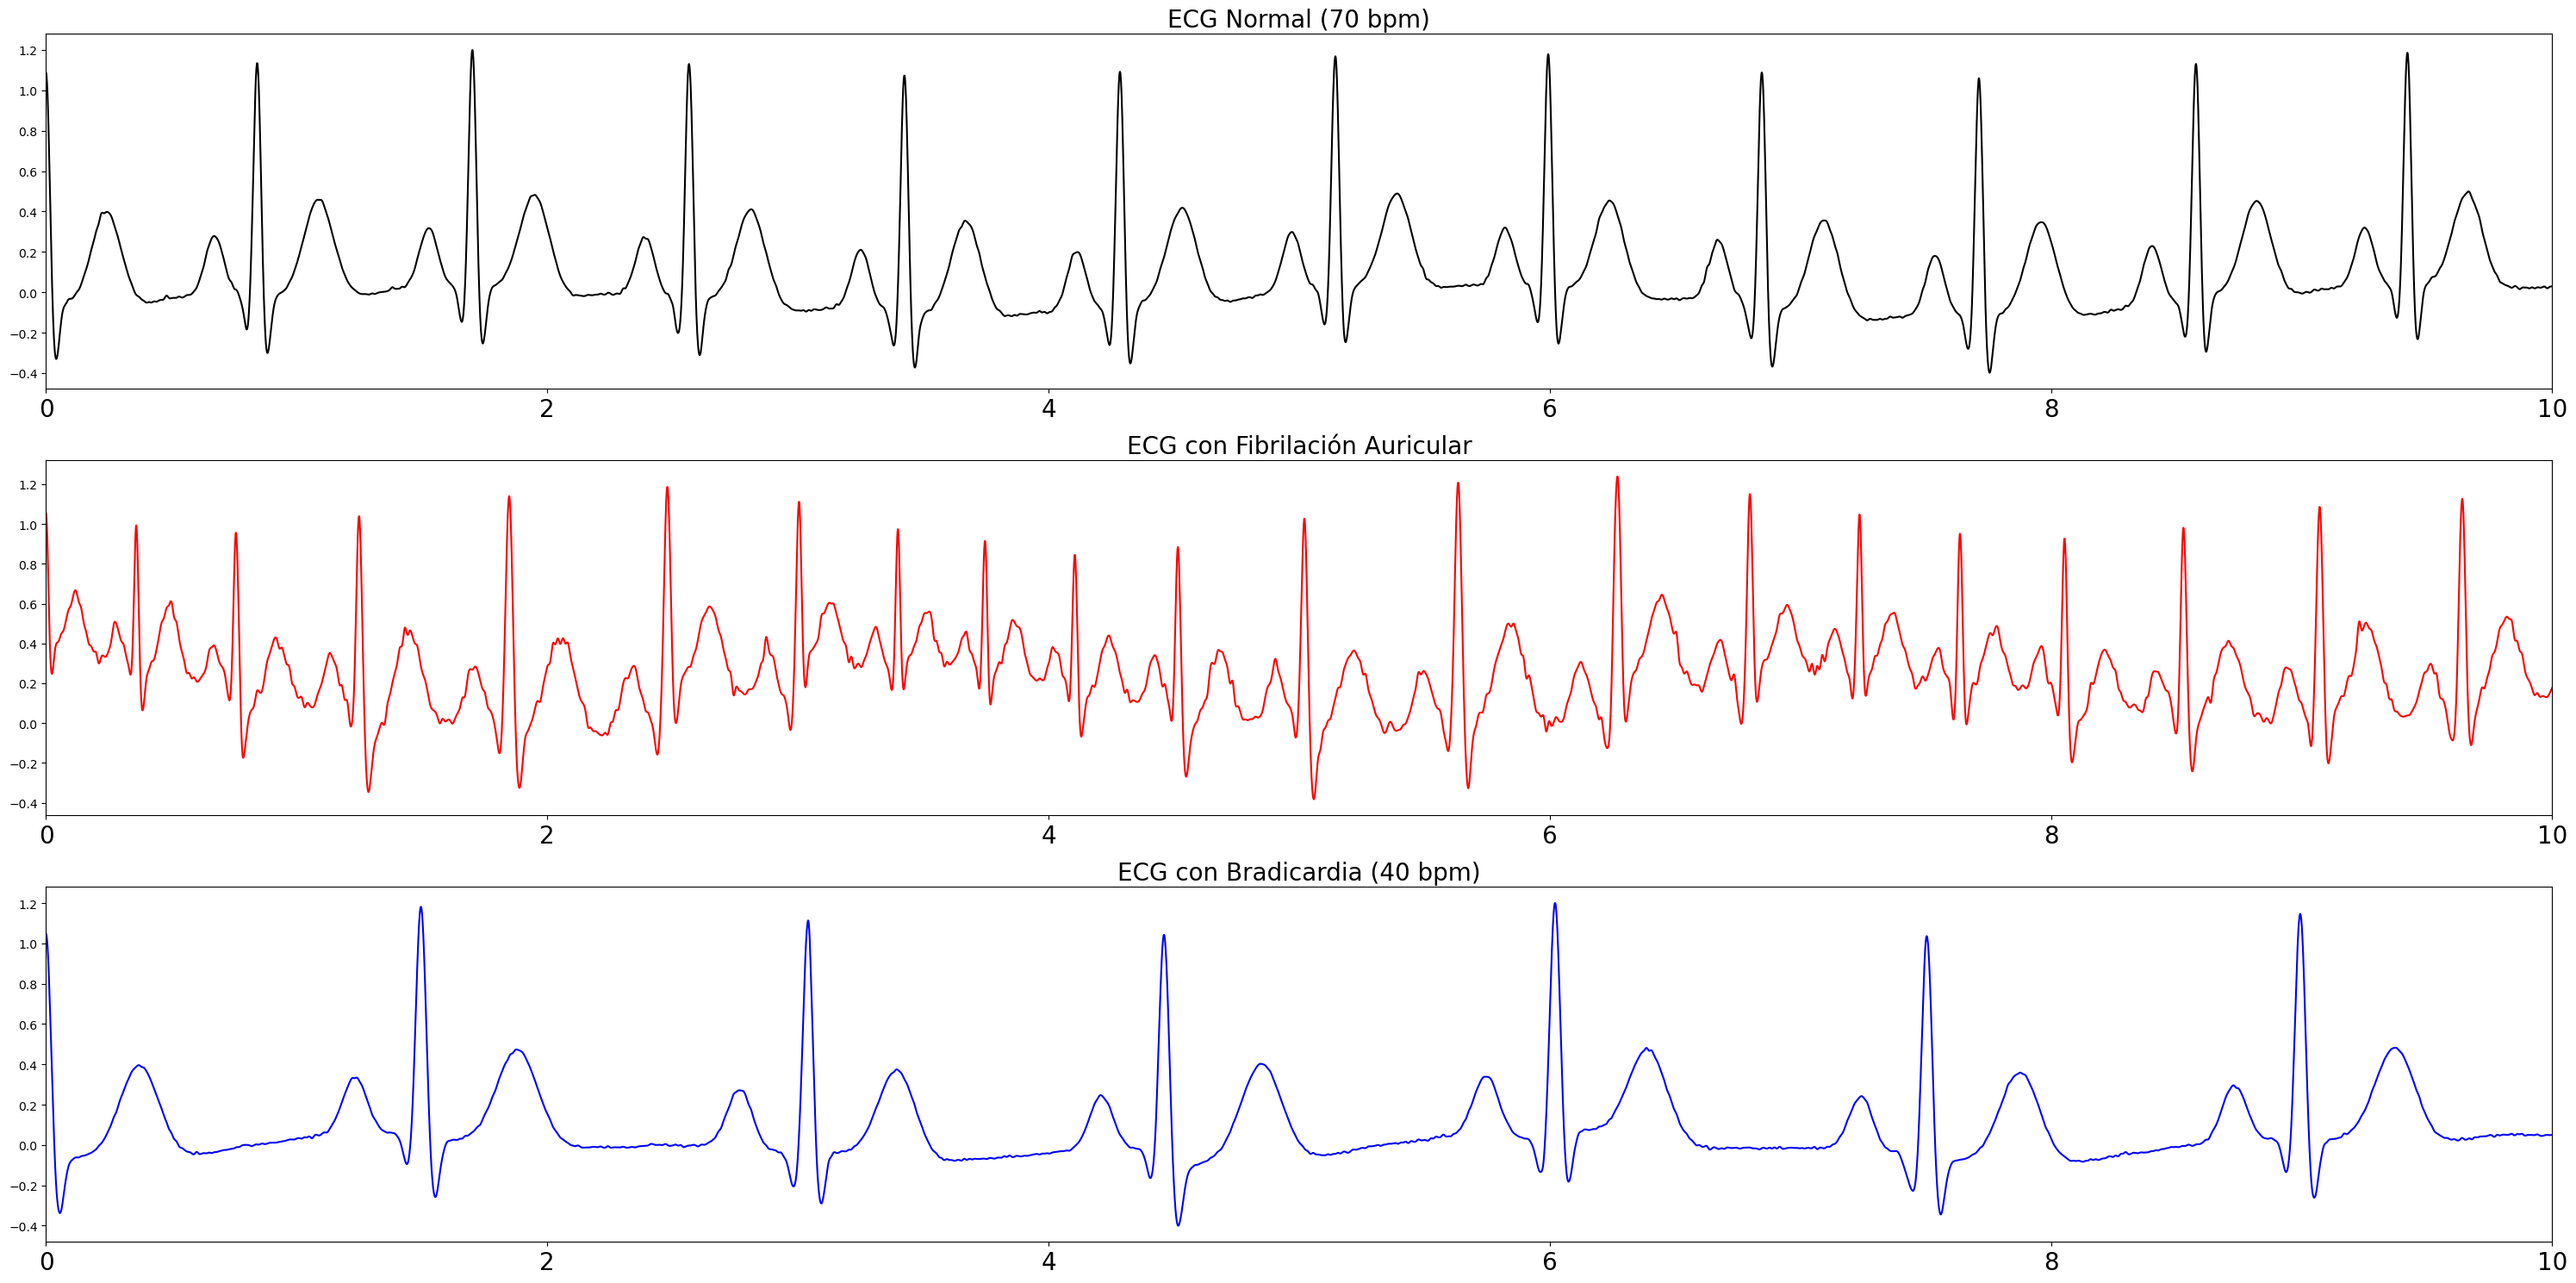

In [33]:
ecg_normal = nk.ecg_simulate(duration=10, heart_rate=70, noise=0.01)
ecg_afib = nk.ecg_simulate(duration=10, heart_rate=120, heart_rate_std=20, noise=0.05) # Atrial Fibrilation
ecg_bradycardia = nk.ecg_simulate(duration=10, heart_rate=40, noise=0.01) # Bradycardia
fs=1000;t = np.linspace(0, len(ecg_normal)/fs, len(ecg_normal));

plt.figure(figsize=(30, 15))

plt.subplot(3, 1, 1);plt.plot(t,ecg_normal, color='black')
plt.title("ECG Normal (70 bpm)", fontsize=20);plt.xlim(0, t[-1]);plt.tick_params(axis='x', labelsize=20);
plt.subplot(3, 1, 2);plt.plot(t,ecg_afib, color='red')
plt.title("ECG con Fibrilación Auricular",fontsize=20);plt.xlim(0, t[-1]);plt.tick_params(axis='x', labelsize=20);
plt.subplot(3, 1, 3);plt.plot(t,ecg_bradycardia, color='blue')
plt.title("ECG con Bradicardia (40 bpm)",fontsize=20);plt.xlim(0, t[-1]);plt.tick_params(axis='x', labelsize=20);

plt.tight_layout()
plt.show()

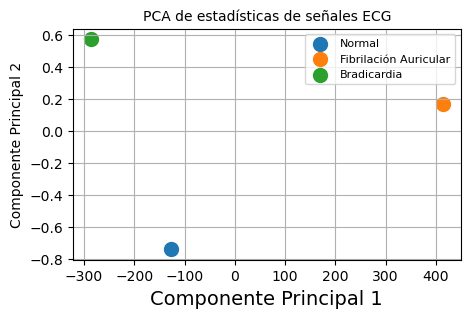

In [44]:
features_normal = extraer_estadisticas_ecg(ecg_normal)
features_afib = extraer_estadisticas_ecg(ecg_afib)
features_brady = extraer_estadisticas_ecg(ecg_bradycardia)

df_features = pd.DataFrame([features_normal, features_afib, features_brady])
df_features["label"] = ["Normal", "Fibrilación Auricular", "Bradicardia"]

X = df_features.drop(columns=["label"])
y = df_features["label"]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(5,3))
for label in y.unique():
    idx = y == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=label, s=100)

plt.title("PCA de estadísticas de señales ECG", fontsize=10)
plt.xlabel("Componente Principal 1", fontsize=14);plt.ylabel("Componente Principal 2", fontsize=10);
plt.legend(fontsize=8);plt.grid(True);plt.show();

### Actividad 4

* De las 3 señales EKG creada, creado 3 mas adicionales con las mismas caracteristicas de estas 3 iniciales.
* Extrae sus caracteristicas y ponlos en una tabla en pandas, luego etiqueta estas señales. ejemplo: 0,1,2.
* Reduce las dimensionalidad a 2 y grafica si existe separabilidad.

In [47]:
def generar_dataset_ecg(n_normales, n_afib, n_bradi, fs=1000, duracion=10):
    data = []

    # Señales normales
    for _ in range(n_normales):
        sig = nk.ecg_simulate(duration=duracion, heart_rate=70, noise=0.01)
        features = extraer_estadisticas_ecg(sig)
        features["label"] = "Normal"
        data.append(features)

    # Señales con fibrilación auricular
    for _ in range(n_afib):
        sig = nk.ecg_simulate(duration=duracion, heart_rate=120, heart_rate_std=20, noise=0.05)
        features = extraer_estadisticas_ecg(sig)
        features["label"] = "Fibrilación Auricular"
        data.append(features)

    # Señales con bradicardia
    for _ in range(n_bradi):
        sig = nk.ecg_simulate(duration=duracion, heart_rate=40, noise=0.01)
        features = extraer_estadisticas_ecg(sig)
        features["label"] = "Bradicardia"
        data.append(features)
    
    return pd.DataFrame(data)

df_ecg = generar_dataset_ecg(n_normales=10, n_afib=10, n_bradi=10)
print(df_ecg)

        mean    median  kurtosis  skewness       energy                  label
0   0.118234  0.055319  4.255885  1.633349   693.256351                 Normal
1   0.107821  0.035251  4.611347  1.725683   672.205082                 Normal
2   0.089107  0.018432  4.624287  1.732106   600.623589                 Normal
3   0.099977  0.027057  4.478456  1.714375   649.618121                 Normal
4   0.081934  0.005184  4.682665  1.757605   632.187314                 Normal
5   0.122053  0.059106  4.324091  1.655868   701.694379                 Normal
6   0.193382  0.145984  4.142749  1.543503   835.731133                 Normal
7   0.100496  0.036245  4.412676  1.676022   662.100528                 Normal
8   0.112955  0.051636  4.376020  1.667605   682.095599                 Normal
9   0.111957  0.036510  4.589321  1.742102   674.725715                 Normal
10  0.267904  0.250549  1.925575  0.870130  1220.444320  Fibrilación Auricular
11  0.341917  0.330298  1.576820  0.621398  1642.997

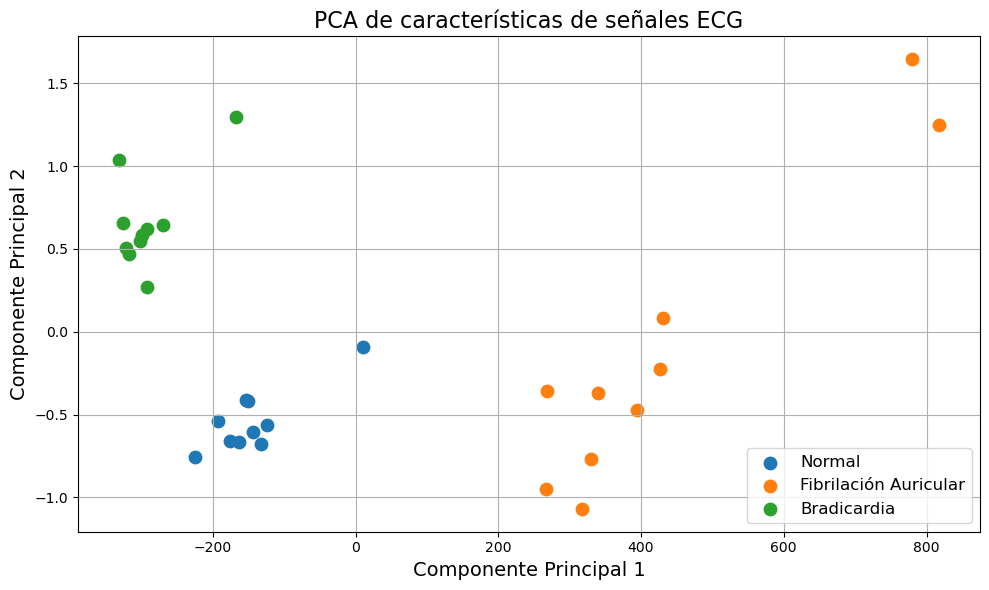

In [49]:
def graficar_pca(df, title="PCA de características de señales ECG"):

    X = df.drop(columns=["label"])
    y = df["label"]

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(10, 6))
    for etiqueta in y.unique():
        idx = y == etiqueta
        plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=etiqueta, s=80)

    plt.title(title, fontsize=16)
    plt.xlabel("Componente Principal 1", fontsize=14); plt.ylabel("Componente Principal 2", fontsize=14);plt.legend(fontsize=12);
    plt.grid(True);plt.tight_layout()
    plt.show()
graficar_pca(df_ecg)

### Actividad para casa

* Continuar con la actividad de clase pero incluir los coeficientes de DWT.

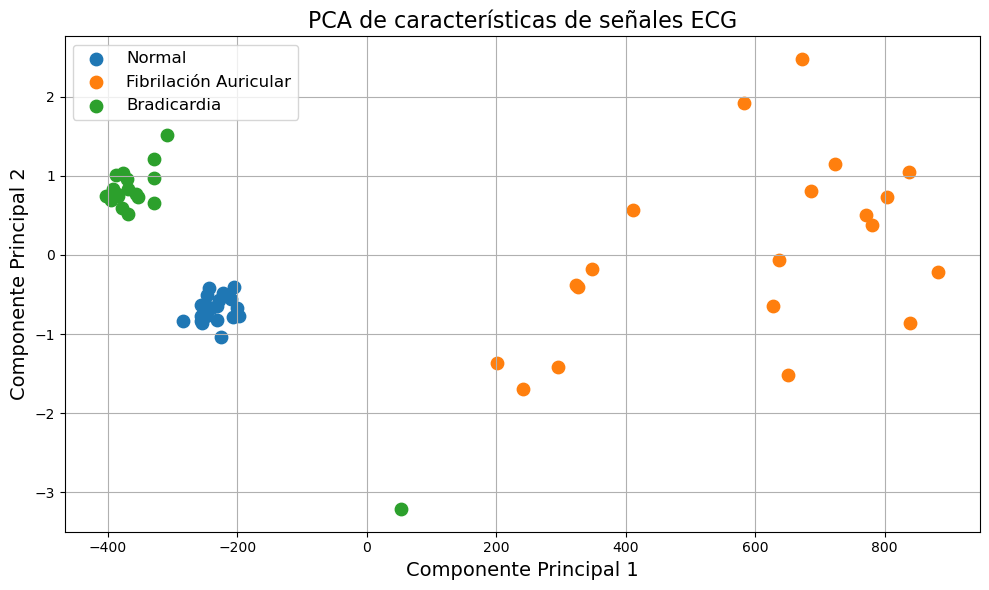

In [58]:
def extraer_caracteristicas_ecg_completo(senal, n_coef=10):
    features = {
        "mean": np.mean(senal),
        "median": np.median(senal),
        "kurtosis": kurtosis(senal),
        "skewness": skew(senal),
        "energy": np.sum(np.square(senal))
    }

    # DWT - usamos Daubechies 4 (db4), común para ECG
    coeffs = pywt.wavedec(senal, 'db4', level=4)

    # Nos quedamos con los primeros n_coef de los coeficientes de aproximación (nivel más bajo)
    approx = coeffs[0][:n_coef]

    for i, val in enumerate(approx):
        features[f'dwt_coef_{i+1}'] = val

    return features

def generar_dataset_ecg(n_normales, n_afib, n_bradi, fs=1000, duracion=10):
    data = []
    
    for _ in range(n_normales):
        sig = nk.ecg_simulate(duration=duracion, heart_rate=70, noise=0.01)
        features = extraer_caracteristicas_ecg_completo(sig)
        features["label"] = "Normal"
        data.append(features)

    for _ in range(n_afib):
        sig = nk.ecg_simulate(duration=duracion, heart_rate=120, heart_rate_std=20, noise=0.05)
        features = extraer_caracteristicas_ecg_completo(sig)
        features["label"] = "Fibrilación Auricular"
        data.append(features)

    for _ in range(n_bradi):
        sig = nk.ecg_simulate(duration=duracion, heart_rate=40, noise=0.01)
        features = extraer_caracteristicas_ecg_completo(sig)
        features["label"] = "Bradicardia"
        data.append(features)
    
    return pd.DataFrame(data)

df_ecg = generar_dataset_ecg(n_normales=20, n_afib=20, n_bradi=20)
graficar_pca(df_ecg)

Este inciso de incluir coeficientes DWT (Discrete Wavelet Transform) apunta a enriquecer las características extraídas de las señales ECG, lo que mejora la discriminación entre clases. Por tanto, los coeficientes DWT se deben incluir en la etapa de extracción de características, junto a las estadísticas que ya estamos extrayendo.